In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

Load + clean data

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from src.data.load_data import load_data

df = load_data()

# Clean
df = df.dropna()

# Convert target to binary
df.loc[:, "target"] = df["target"].apply(lambda x: 1 if x > 0 else 0)

print(df.shape)
df.head()

Loading from: /Users/shsanjay/mlops-heart-disease/data/heart.csv
Dataset loaded successfully

Shape: (303, 14)
(297, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Histograms
## Feature Distributions

Most numerical features such as age, cholesterol, and maximum heart rate show varied distributions. Some features are slightly skewed, indicating potential influence on model performance.

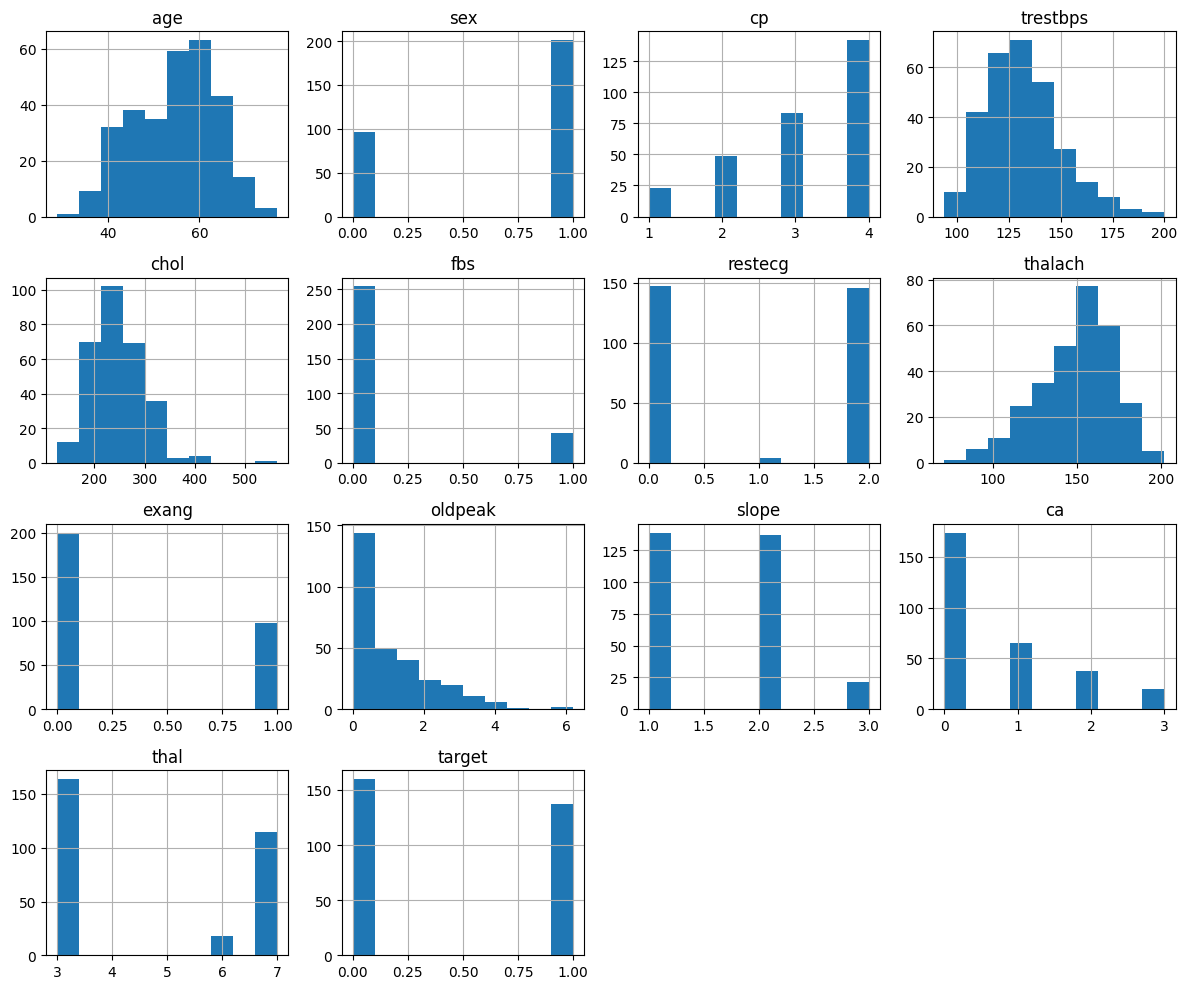

In [4]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

## Heatmap
## Correlation Analysis

The heatmap shows relationships between features. Variables like `thalach` and `oldpeak` show noticeable correlation with the target, suggesting their importance in predicting heart disease.

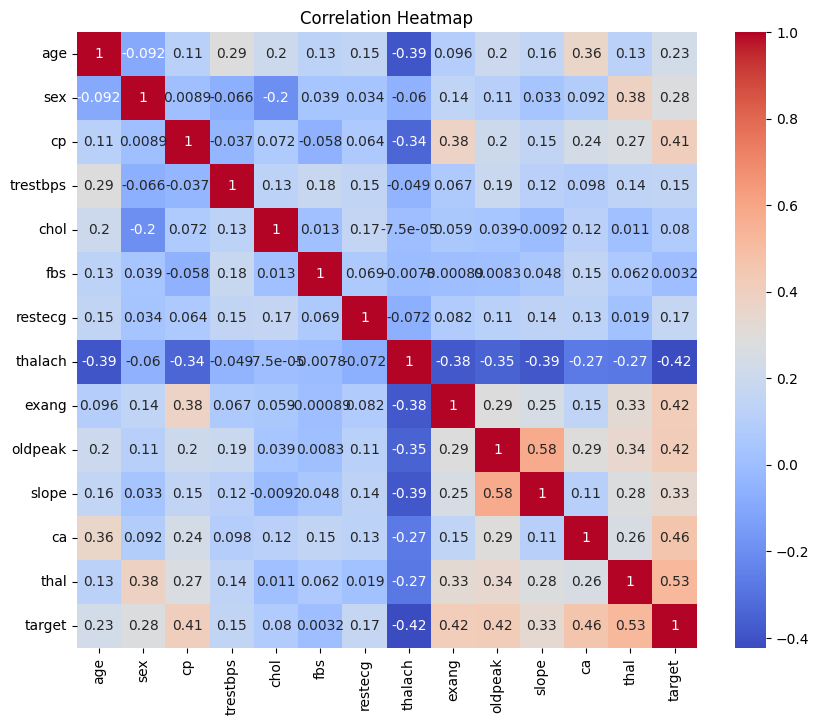

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Target Class Distribution

The dataset is relatively balanced, with approximately 160 samples without heart disease and 137 with heart disease. This reduces the need for imbalance handling techniques.

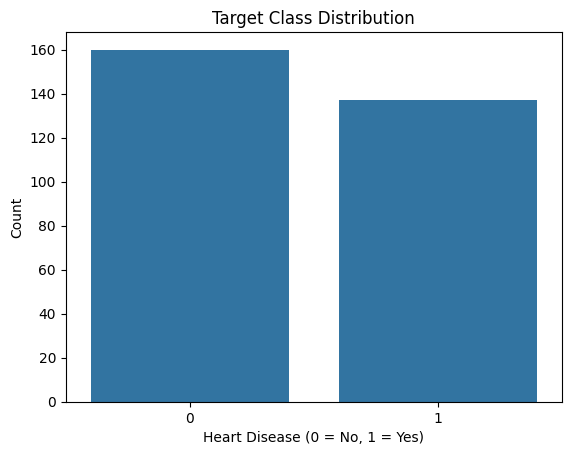

In [6]:
sns.countplot(x="target", data=df)
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()